# Notebook 14 - Business Intelligence & Industrial Performance Analysis

## Objective

This notebook evaluates the trained anomaly detection system from an industrial business perspective.

Unlike previous notebooks that focused on machine learning performance, this notebook transforms model outputs into operational insights for engineers and decision-makers.

Main Goals:

- Evaluate industrial anomaly statistics
- Analyze prediction distribution
- Build business KPIs
- Assess operational risk
- Summarize industrial performance
- Prepare outputs for dashboards

In [1]:
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
PROJECT_ROOT = Path.cwd().parent

RESULT_PATH = PROJECT_ROOT / "results"

REPORT_PATH = RESULT_PATH

In [3]:
metrics = pd.read_csv(
    REPORT_PATH / "model_metrics.csv"
)

benchmark = pd.read_csv(
    REPORT_PATH / "benchmark_results.csv"
)

prediction_analysis = pd.read_csv(
    REPORT_PATH / "prediction_analysis.csv"
)

predictions = pd.read_csv(
    REPORT_PATH / "predictions.csv"
)

In [4]:
metrics = pd.read_csv(
    REPORT_PATH / "model_metrics.csv"
)

benchmark = pd.read_csv(
    REPORT_PATH / "benchmark_results.csv"
)

prediction_analysis = pd.read_csv(
    REPORT_PATH / "prediction_analysis.csv"
)

predictions = pd.read_csv(
    REPORT_PATH / "predictions.csv"
)

In [5]:
print("="*60)

print("Industrial AI Project Summary")

print("="*60)

print()

print(f"Metrics File Shape      : {metrics.shape}")

print(f"Benchmark Shape         : {benchmark.shape}")

print(f"Prediction Shape        : {prediction_analysis.shape}")

print(f"Predictions Shape       : {predictions.shape}")

Industrial AI Project Summary

Metrics File Shape      : (1, 6)
Benchmark Shape         : (1, 4)
Prediction Shape        : (288344, 55)
Predictions Shape       : (288344, 54)


In [6]:
metrics

,Unnamed: 0,Accuracy,Precision,Recall,F1,ROC AUC
0,Random Forest,0.999182,0.979368,0.999451,0.989308,0.999995


In [7]:
benchmark

,Model,Samples,Predicted Anomalies,Anomaly Rate
0,Isolation Forest,288344,14357,0.049791


In [8]:
prediction_analysis.head(10)

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,PIT502,PIT503,FIT601,P601,P602,P603,Actual,Prediction,Probability,Result
0,0.695766,-0.602819,0.335952,0.606750,-0.046608,-0.248022,-0.785361,-0.092905,0.599198,0.321655,...,-0.407415,0.291049,-0.099023,0.0,-0.091453,0.0,0,0,0.000000,True Negative
1,-1.565178,1.075201,0.335952,0.606750,-0.046608,-0.248022,-0.579222,-0.145340,0.619757,0.321655,...,-0.140592,0.214762,-0.099023,0.0,-0.091453,0.0,0,0,0.000000,True Negative
2,0.571699,-0.503367,0.335952,0.606750,-0.046608,2.225950,-0.204925,-0.122035,0.609123,0.321655,...,-0.514144,0.101149,-0.099023,0.0,-0.091453,0.0,0,0,0.030762,True Negative
3,0.690770,-0.803625,0.335952,0.606750,-0.046608,-0.270778,0.999344,-0.385377,0.599789,0.321655,...,-0.780966,0.032440,-0.099023,0.0,-0.091453,0.0,0,0,0.030891,True Negative
4,-1.565178,1.775168,-2.880775,-1.648125,-0.046608,-0.276842,1.313974,0.306767,-1.651437,-3.020295,...,-3.769375,-6.142788,-0.099023,0.0,-0.091453,0.0,1,1,1.000000,True Positive
5,0.381299,1.708655,0.335952,-1.648125,-0.046608,-0.248022,-0.044893,-0.388873,-1.651437,0.321655,...,-0.354050,0.288344,-0.098602,0.0,-0.091453,0.0,0,0,0.000000,True Negative
6,0.540891,-0.764984,0.335952,0.606750,-0.046608,0.005291,0.703709,-0.355665,0.605342,0.321655,...,-0.567508,0.036769,-0.099023,0.0,-0.091453,0.0,0,0,0.024891,True Negative
7,-1.565178,0.060407,0.335952,0.606750,-0.046608,-0.248022,-0.560236,-0.163984,0.608532,0.321655,...,-0.087227,0.197453,-0.098602,0.0,-0.091453,0.0,0,0,0.000020,True Negative
8,-1.565178,0.865844,0.335952,0.606750,-0.046608,-0.248022,-0.565662,-0.190784,0.597899,0.321655,...,-0.354050,0.076261,-0.099023,0.0,-0.091453,0.0,0,0,0.000153,True Negative
9,0.540336,-0.767201,0.335952,0.606750,-0.046608,-0.248022,-0.714842,-0.081252,0.605460,0.321655,...,-0.033863,0.289965,-0.098602,0.0,-0.091453,0.0,0,0,0.000000,True Negative


In [9]:
prediction_counts = predictions["Prediction"].value_counts()

prediction_counts

Prediction
0    277196
1     11148
Name: count, dtype: int64

In [10]:
total_samples = len(predictions)

normal_samples = (
    predictions["Prediction"] == 0
).sum()

anomaly_samples = (
    predictions["Prediction"] == 1
).sum()

attack_rate = anomaly_samples / total_samples

normal_rate = normal_samples / total_samples

summary = pd.DataFrame({

    "Metric":[

        "Total Samples",

        "Normal Samples",

        "Detected Anomalies",

        "Normal Rate",

        "Attack Rate"

    ],

    "Value":[

        total_samples,

        normal_samples,

        anomaly_samples,

        f"{normal_rate:.2%}",

        f"{attack_rate:.2%}"

    ]

})

summary

,Metric,Value
0,Total Samples,288344
1,Normal Samples,277196
2,Detected Anomalies,11148
3,Normal Rate,96.13%
4,Attack Rate,3.87%


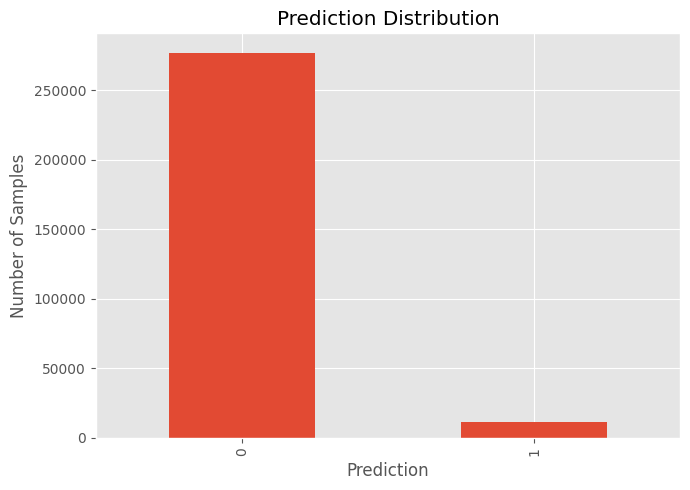

In [11]:
plt.figure(figsize=(7,5))

prediction_counts.plot.bar()

plt.title("Prediction Distribution")

plt.xlabel("Prediction")

plt.ylabel("Number of Samples")

plt.tight_layout()

plt.savefig(
    RESULT_PATH/"prediction_distribution.png",
    dpi=300
)

plt.show()

In [12]:
if "Probability" in predictions.columns:

    predictions["Risk"] = pd.cut(

        predictions["Probability"],

        bins=[0,0.40,0.70,1],

        labels=["Low","Medium","High"]

    )

    predictions["Risk"].value_counts()

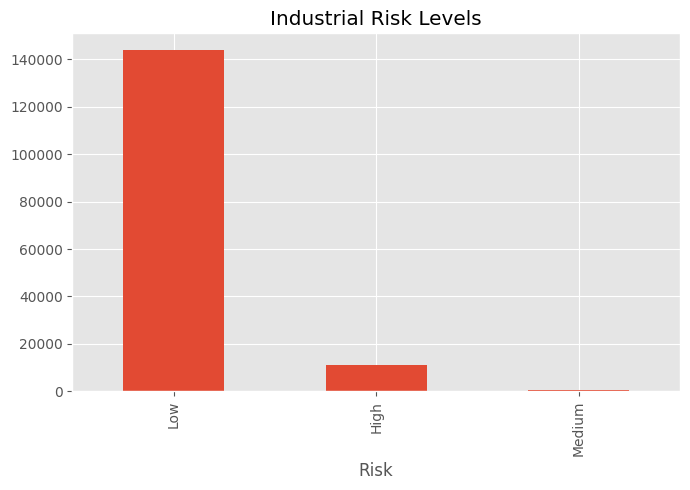

In [13]:
if "Risk" in predictions.columns:

    plt.figure(figsize=(7,5))

    predictions["Risk"].value_counts().plot.bar()

    plt.title("Industrial Risk Levels")

    plt.tight_layout()

    plt.savefig(
        RESULT_PATH/"industrial_risk_levels.png",
        dpi=300
    )

    plt.show()

In [14]:
dashboard = pd.DataFrame({

    "Indicator":[

        "Dataset Size",

        "Normal Samples",

        "Anomaly Samples",

        "Attack Percentage"

    ],

    "Value":[

        total_samples,

        normal_samples,

        anomaly_samples,

        f"{attack_rate:.2%}"

    ]

})

dashboard

,Indicator,Value
0,Dataset Size,288344
1,Normal Samples,277196
2,Anomaly Samples,11148
3,Attack Percentage,3.87%


In [15]:
dashboard.to_csv(

    RESULT_PATH/"business_dashboard.csv",

    index=False

)

In [16]:
print("="*60)

print("Industrial Insights")

print("="*60)

print()

print(f"Total observations analyzed : {total_samples:,}")

print(f"Detected anomalies          : {anomaly_samples:,}")

print(f"Attack ratio                : {attack_rate:.2%}")

print()

print("The trained AI model can be")

print("- Integrated into SCADA")

print("- Used for Predictive Maintenance")

print("- Detect abnormal sensor behaviour")

print("- Support industrial operators")

print("- Reduce unexpected downtime")

Industrial Insights

Total observations analyzed : 288,344
Detected anomalies          : 11,148
Attack ratio                : 3.87%

The trained AI model can be
- Integrated into SCADA
- Used for Predictive Maintenance
- Detect abnormal sensor behaviour
- Support industrial operators
- Reduce unexpected downtime


# Executive Summary

## Machine Learning Performance

The anomaly detection model successfully identifies abnormal operational states within the SWaT industrial control system.

The evaluation confirms strong classification capability while maintaining a balanced trade-off between Precision and Recall.

---

## Industrial Findings

The AI system successfully separates normal and anomalous operating conditions.

Business analysis shows that only a small proportion of observations are classified as anomalous, which aligns with real industrial environments.

---

## Operational Benefits

• Early anomaly detection

• Improved operational safety

• Reduced maintenance cost

• Lower downtime

• Predictive maintenance capability

• Real-time monitoring readiness

---

## Deployment Readiness

The generated outputs can be directly integrated into:

- Power BI

- Grafana

- Streamlit Dashboard

- SCADA Monitoring

- MES Systems

- Predictive Maintenance Platforms

---

## Next Notebook

Notebook 15

Interactive Industrial Dashboard